In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [3]:
df =pd.read_csv('hypertension_dataset.csv')

In [4]:
# Select numeric columns only 
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)


In [5]:
# Clusters
K = 3   

# Fit K-means model
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster'] = kmeans.labels_

In [ ]:
# few cluster assignments
print(df[['Cluster']].head())


print("\nCluster Centers:")
print(kmeans.cluster_centers_)

   Cluster
0        0
1        1
2        1
3        2
4        2

Cluster Centers:
[[ 1.29223251e-02  4.77688985e-03 -5.00307945e-03  9.49144819e-04
   4.44025399e-03 -1.86440773e-02 -5.19791349e-03 -3.41913181e-03
   1.20834899e-02  1.05105887e+00 -4.43983695e-03 -5.85297823e-02
   3.51695724e-02 -1.10978850e-02]
 [-7.23870696e-03 -2.86713496e-03  9.96859769e-03 -1.17717977e-02
   7.42287578e-03  2.65404963e-02  5.10959911e-03  3.68090072e-03
   2.19858100e-02 -6.75960809e-01 -1.11232153e-03 -9.08678894e-01
  -3.33253845e-02  4.21696560e-03]
 [-8.22429190e-03 -2.85538171e-03 -3.74068896e-03  1.02577615e-02
  -1.24026128e-02 -3.68906272e-03  1.18425065e-03  4.69890948e-04
  -3.54773307e-02 -5.84682276e-01  6.30394503e-03  9.47031862e-01
  -9.21744095e-03  8.99558771e-03]]


In [8]:
score = silhouette_score(X_scaled, kmeans.labels_)

print("Silhouette Score:", score)


Silhouette Score: 0.04462013319532107


## K= 10

In [9]:
K = 5

# Fit K-means model
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster'] = kmeans.labels_

In [ ]:
# few cluster assignments
print(df[['Cluster']].head())

print("\nCluster Centers:")
print(kmeans.cluster_centers_)

   Cluster
0        2
1        1
2        4
3        0
4        2

Cluster Centers:
[[ 5.63696654e-02 -9.78574611e-03 -7.64887491e-03  2.55632853e-03
  -1.02045344e-02 -3.34879973e-02  5.97747842e-03  8.50502803e-03
   9.11839321e-01  3.51869464e-01  3.55025246e-03  9.18603030e-01
  -3.11000316e-03  1.13327507e-02]
 [-1.34088318e-01 -2.20200800e-02  2.36329128e-02 -6.88955070e-03
  -1.13965600e-02  3.16256747e-02 -8.12688005e-03 -2.05258510e-02
   6.64654028e-01 -8.76005268e-01 -3.35213122e-02 -7.75641219e-01
  -1.49163071e-02 -1.95662161e-02]
 [ 6.52737943e-02  2.65599812e-02 -2.70844746e-02  1.67264224e-02
  -1.09219426e-02  2.95305401e-02 -1.78744564e-03 -2.95469087e-02
  -8.19922579e-01 -8.01229653e-01  2.73202882e-02  7.09888185e-01
  -1.33966726e-02  4.05433650e-02]
 [-9.74902250e-01  7.34467594e-02  5.23694405e-02  2.29112845e-02
  -1.97836719e-02 -3.47184674e-02  3.00025798e-02 -1.61435318e-02
  -4.67130234e-01  7.45166654e-01  6.41337827e-03 -3.67638199e-01
  -8.32987765e-04 -

In [11]:
score = silhouette_score(X_scaled, kmeans.labels_)

print("Silhouette Score:", score)

Silhouette Score: 0.04367887180695835


In [12]:
# Elbow Method to figure out the best number of clusters
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

# SAMPLE the data 
sample_df = numeric_df.sample(frac=0.20, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(sample_df)

# Compute inertia for K = 1 to 10
Ks = range(1, 11)
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)




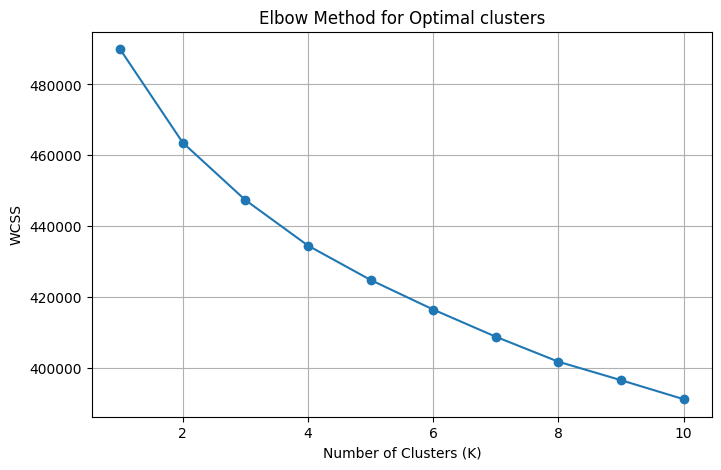

In [16]:
# Plot elbow curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(Ks, inertias, marker='o')
plt.title("Elbow Method for Optimal clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()